# Cross-Evaluation of Fine-Tuned TrOCR on the George Washington Dataset
Evaluate the TrOCR model (fine-tuned on Bentham) on the George Washington (GW) dataset to measure cross-domain generalization.

### Workflow
1. Install dependencies
2. Set random seed for reproducibility
3. Set all paths
4. Explore the GW dataset structure
5. Build the GW transcription decoder
6. Load all transcriptions into a dictionary
7. Build the GW Dataset class
8. Load the fine-tuned TrOCR model
9. Define CER / WER metrics and predict function
10. Define the evaluation loop
11. Discover fold file names
12. Run 4-fold cross-evaluation
13. Summarize and save results

### Dataset
- George Washington
- Already line-level binarized and normalized PNG images
- Ground-truth transcription file
- 4-fold cross-validation splits provided

In [1]:
from pathlib import Path
import os
import random

import pandas as pd
import numpy as np
import cv2
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel
)

import editdistance
from jiwer import wer
from tqdm import tqdm

In [2]:
RSEED = 42

random.seed(RSEED)
np.random.seed(RSEED)
torch.manual_seed(RSEED)

if torch.backends.mps.is_available():
    print('True')
    torch.mps.manual_seed(RSEED)

True


In [3]:
# Select MPS (Apple Silicon) for acceleration
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: mps


In [4]:
# Setting path to GW dataset
GW_ROOT    = Path("data")     
MODEL_PATH = Path("best_ar")  

GW_LINES_DIR          = GW_ROOT / "washingtondb-v1.0" / "data" / "line_images_normalized"
GW_TRANSCRIPTION_FILE = GW_ROOT / "washingtondb-v1.0" / "ground_truth" / "transcription.txt"
GW_SETS_DIR           = GW_ROOT / "washingtondb-v1.0" / "sets"

OUTPUT_CSV = Path("gw_cross_evaluation_results.csv")

# Sanity check
for p in [GW_LINES_DIR, GW_TRANSCRIPTION_FILE, GW_SETS_DIR, MODEL_PATH]:
    status = "OK" if p.exists() else "NOT FOUND"
    print(f"[{status}] {p}")

[OK] data/washingtondb-v1.0/data/line_images_normalized
[OK] data/washingtondb-v1.0/ground_truth/transcription.txt
[OK] data/washingtondb-v1.0/sets
[OK] best_ar


According to the README.txt file provided for the GW dataset:

GW transcriptions encode each character separately with `-` and use special tokens for punctuation (e.g. `s_pt` = `.`, `s_cm` = `,`). This cell decodes them into plain readable text.

In [5]:
# Mapping of GW special tokens to plain characters
SPECIAL_CHARS = {
    "s_pt":  ".",
    "s_cm":  ",",
    "s_mi":  "-",
    "s_qo":  ":",
    "s_sq":  ";",
    "s_et":  "&",
    "s_bl":  "|",
    "s_br":  " ",
    "s_1st": "1st",
    "s_s":   "s",  
}

def decode_gw_word(word_str):
    """Convert a single GW word token (e.g. 't-h-e' or 's_pt') to plain text."""
    chars = word_str.split("-")
    result = ""
    for ch in chars:
        if ch in SPECIAL_CHARS:
            result += SPECIAL_CHARS[ch]
        else:
            result += ch
    return result


def decode_gw_line(raw_line):
    """
    Format: '270-01 word1|word2|word3'
    Returns: (line_id, plain_text) or (None, None) if malformed.
    """
    parts = raw_line.strip().split(" ", 1)
    if len(parts) < 2:
        return None, None
    line_id = parts[0]
    words   = parts[1].split("|")
    text    = " ".join(decode_gw_word(w) for w in words)
    return line_id, text


# Quick sanity check
test_raw = "270-01 t-h-e|s_pt|q-u-i-c-k"
lid, txt = decode_gw_line(test_raw)
print(f"Line ID : {lid}")
print(f"Decoded : {txt}")

Line ID : 270-01
Decoded : the . quick


In [6]:
# Load all ground-truth transcriptions into a dictionary
gw_transcriptions = {}

with open(GW_TRANSCRIPTION_FILE, "r", encoding="utf-8") as f:
    for raw_line in f:
        line_id, text = decode_gw_line(raw_line)
        if line_id and text:
            gw_transcriptions[line_id] = text

print(f"Total transcribed lines loaded: {len(gw_transcriptions)}")
print("\nSample entries:")
for k, v in list(gw_transcriptions.items())[:5]:
    print(f"  {k}  →  {v}")

Total transcribed lines loaded: 656

Sample entries:
  270-01  →  s_2s_7s_0. Letters, Orders and Instructions. October s_1s_7s_5s_5.
  270-03  →  only for the publick use, unless by particu-
  270-04  →  lar Orders from me. You are to send
  270-05  →  down a Barrel of Flints with the Arms, to
  270-06  →  Winchester, and about two thousand weight


In [7]:
# Applying the Bentham pipeline to GW dataset: convert grayscale to CLAHE to RGB to TrOCR processor.
class GWDataset(Dataset):

    def __init__(self, line_ids, image_dir, transcriptions, processor):
        # Keep only IDs that have both an image and a transcription
        self.line_ids = [
            lid for lid in line_ids
            if lid in transcriptions
            and (image_dir / f"{lid}.png").exists()
        ]
        self.image_dir      = image_dir
        self.transcriptions = transcriptions
        self.processor      = processor

        skipped = len(line_ids) - len(self.line_ids)
        if skipped > 0:
            print(f"  Skipped {skipped} IDs (missing image or transcription)")

    def __len__(self):
        return len(self.line_ids)

    def __getitem__(self, idx):
        line_id    = self.line_ids[idx]
        image_path = self.image_dir / f"{line_id}.png"

        # Same preprocessing as Bentham: CLAHE → RGB
        gray     = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        image    = Image.fromarray(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB))

        text = self.transcriptions[line_id]

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}

In [8]:
# Load the fine-tuned TrOCR model and processor
processor = TrOCRProcessor.from_pretrained(str(MODEL_PATH))
model     = VisionEncoderDecoderModel.from_pretrained(str(MODEL_PATH))
model.to(device)
model.eval()

tokenizer = processor.tokenizer

print("Model loaded and moved to", device)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Model loaded and moved to mps


In [9]:
# Collator function similar to what we did for BH dataset
def collate_fn(batch):

    pixel_values = torch.stack(
        [item["pixel_values"] for item in batch]
    )

    labels = torch.nn.utils.rnn.pad_sequence(
        [item["labels"] for item in batch],
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )

    # Mask padding so it is ignored in loss
    labels[labels == tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels}

In [10]:
# CER / WER metrics and predict
def cer(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    return wer(gt, pred)


def predict(pixel_values, num_beams=8):
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            num_beams=num_beams,
            early_stopping=True,
            max_new_tokens=128,
            no_repeat_ngram_size=3,
        )
    return processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )

In [11]:
# Evaluation loop
def evaluate(loader, desc="Evaluating"):

    model.eval()

    total_cer = 0
    total_wer = 0
    count     = 0

    with torch.no_grad():

        for batch in tqdm(loader, desc=desc):

            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"]

            preds = predict(pixel_values)

            for i in range(len(preds)):

                pred   = preds[i]
                gt_ids = labels[i].clone()

                # Remove ignore tokens
                gt_ids[gt_ids == -100] = tokenizer.pad_token_id

                gt = tokenizer.decode(
                    gt_ids, skip_special_tokens=True
                )

                total_cer += cer(pred, gt)
                total_wer += compute_wer(pred, gt)
                count     += 1

    return total_cer / count, total_wer / count

In [12]:
# The exact file names inside sets folder: each cross validation experiment is stored 
# in a folder named accordingly
print("Files found in sets/:")
for root, dirs, files in os.walk(GW_SETS_DIR):
    for fname in sorted(files):
        full = os.path.join(root, fname)
        print(" ", full)
        # Try to preview first 3 line IDs — skip binary files
        try:
            with open(full, "r", encoding="utf-8") as f:
                for i, line in enumerate(f):
                    print(f"    sample ID: {line.strip()}")
                    if i >= 2:
                        break
        except UnicodeDecodeError:
            print("    [binary file — skipping preview]")

Files found in sets/:
  data/washingtondb-v1.0/sets/.DS_Store
    [binary file — skipping preview]
  data/washingtondb-v1.0/sets/cv3/keywords.txt
    sample ID: A-l-e-x-a-n-d-r-i-a
    sample ID: C-a-p-t-a-i-n
    sample ID: C-l-o-t-h-e-s
  data/washingtondb-v1.0/sets/cv3/test.txt
    sample ID: 275-01
    sample ID: 275-03
    sample ID: 275-04
  data/washingtondb-v1.0/sets/cv3/train.txt
    sample ID: 300-02
    sample ID: 300-04
    sample ID: 300-05
  data/washingtondb-v1.0/sets/cv3/valid.txt
    sample ID: 270-01
    sample ID: 270-03
    sample ID: 270-04
  data/washingtondb-v1.0/sets/cv4/keywords.txt
    sample ID: A-l-e-x-a-n-d-r-i-a-s_qo
    sample ID: B-e-e-v-e-s
    sample ID: C-a-p-t-a-i-n
  data/washingtondb-v1.0/sets/cv4/test.txt
    sample ID: 300-02
    sample ID: 300-04
    sample ID: 300-05
  data/washingtondb-v1.0/sets/cv4/train.txt
    sample ID: 305-01
    sample ID: 305-02
    sample ID: 305-04
  data/washingtondb-v1.0/sets/cv4/valid.txt
    sample ID: 275-01
    

In [13]:
# Folders are named cv1, cv2, cv3, cv4
def get_fold_dir(fold_number):
    return GW_SETS_DIR / f"cv{fold_number}"

# Verify structure for all 4 folds
for fold in range(1, 5):
    fold_dir = get_fold_dir(fold)
    print(f"\nFold {fold}: {fold_dir}")
    for split in ["train.txt", "valid.txt", "test.txt"]:
        p = fold_dir / split
        status = "OK" if p.exists() else "NOT FOUND"
        print(f"  [{status}] {split}")


Fold 1: data/washingtondb-v1.0/sets/cv1
  [OK] train.txt
  [OK] valid.txt
  [OK] test.txt

Fold 2: data/washingtondb-v1.0/sets/cv2
  [OK] train.txt
  [OK] valid.txt
  [OK] test.txt

Fold 3: data/washingtondb-v1.0/sets/cv3
  [OK] train.txt
  [OK] valid.txt
  [OK] test.txt

Fold 4: data/washingtondb-v1.0/sets/cv4
  [OK] train.txt
  [OK] valid.txt
  [OK] test.txt


In [14]:
# Run 4-fold cross-evaluation

BATCH_SIZE = 16

all_fold_results = []

for fold in range(1, 5):

    print(f"\n{'='*50}")
    print(f"Fold {fold} / 4")
    print(f"{'='*50}")

    # Load train + val + test from each cv folder
    fold_dir = GW_SETS_DIR / f"cv{fold}"
    all_ids = []

    for split_file in ["train.txt", "val.txt", "test.txt"]:
        split_path = fold_dir / split_file
        if split_path.exists():
            with open(split_path, "r", encoding="utf-8") as f:
                ids = [line.strip() for line in f if line.strip()]
                all_ids.extend(ids)
            print(f"  Loaded {len(ids)} IDs from {split_file}")
        else:
            print(f"  [{split_file} not found — skipping]")

    # Deduplicate in case any IDs appear in multiple splits
    test_ids = list(dict.fromkeys(all_ids))
    print(f"  Total unique IDs for fold {fold}: {len(test_ids)}")

    # Build dataset and dataloader
    gw_test_dataset = GWDataset(
        test_ids,
        GW_LINES_DIR,
        gw_transcriptions,
        processor
    )

    gw_test_loader = DataLoader(
        gw_test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn
    )

    # Evaluate
    fold_cer, fold_wer = evaluate(
        gw_test_loader,
        desc=f"Fold {fold}"
    )

    print(f"CER: {fold_cer:.4f}")
    print(f"WER: {fold_wer:.4f}")

    all_fold_results.append({
        "fold": fold,
        "test_lines": len(gw_test_dataset),
        "cer": fold_cer,
        "wer": fold_wer
    })


Fold 1 / 4
  Loaded 325 IDs from train.txt
  [val.txt not found — skipping]
  Loaded 163 IDs from test.txt
  Total unique IDs for fold 1: 488


Fold 1: 100%|██████████| 31/31 [07:45<00:00, 15.00s/it]


CER: 0.2096
WER: 0.5960

Fold 2 / 4
  Loaded 329 IDs from train.txt
  [val.txt not found — skipping]
  Loaded 164 IDs from test.txt
  Total unique IDs for fold 2: 493


Fold 2: 100%|██████████| 31/31 [07:52<00:00, 15.24s/it]


CER: 0.1934
WER: 0.5490

Fold 3 / 4
  Loaded 331 IDs from train.txt
  [val.txt not found — skipping]
  Loaded 161 IDs from test.txt
  Total unique IDs for fold 3: 492


Fold 3: 100%|██████████| 31/31 [08:05<00:00, 15.65s/it]


CER: 0.1979
WER: 0.5832

Fold 4 / 4
  Loaded 327 IDs from train.txt
  [val.txt not found — skipping]
  Loaded 168 IDs from test.txt
  Total unique IDs for fold 4: 495


Fold 4: 100%|██████████| 31/31 [07:56<00:00, 15.38s/it]

CER: 0.1750
WER: 0.5422


In [15]:
results_df = pd.DataFrame(all_fold_results)

print("\n===== GW CROSS-EVALUATION RESULTS =====")
print(results_df.to_string(index=False))
print(f"\nMean CER : {results_df['cer'].mean():.4f}")
print(f"Std  CER : {results_df['cer'].std():.4f}")
print(f"Mean WER : {results_df['wer'].mean():.4f}")
print(f"Std  WER : {results_df['wer'].std():.4f}")

results_df


===== GW CROSS-EVALUATION RESULTS =====
 fold  test_lines      cer      wer
    1         488 0.209596 0.595955
    2         493 0.193410 0.549002
    3         492 0.197933 0.583168
    4         495 0.175043 0.542159

Mean CER : 0.1940
Std  CER : 0.0144
Mean WER : 0.5676
Std  WER : 0.0261


,fold,test_lines,cer,wer
0,1,488,0.209596,0.595955
1,2,493,0.193410,0.549002
2,3,492,0.197933,0.583168
3,4,495,0.175043,0.542159


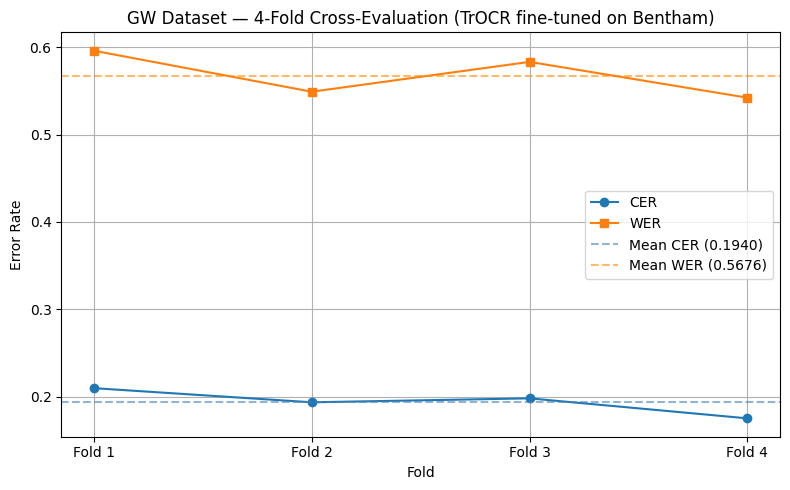

In [16]:
# Plot CER and WER across folds
import matplotlib.pyplot as plt

folds = results_df["fold"]

plt.figure(figsize=(8, 5))
plt.plot(folds, results_df["cer"], marker="o", label="CER")
plt.plot(folds, results_df["wer"], marker="s", label="WER")
plt.axhline(results_df["cer"].mean(), linestyle="--", color="steelblue",
            alpha=0.6, label=f"Mean CER ({results_df['cer'].mean():.4f})")
plt.axhline(results_df["wer"].mean(), linestyle="--", color="darkorange",
            alpha=0.6, label=f"Mean WER ({results_df['wer'].mean():.4f})")
plt.xticks(folds, [f"Fold {i}" for i in folds])
plt.xlabel("Fold")
plt.ylabel("Error Rate")
plt.title("GW Dataset — 4-Fold Cross-Evaluation (TrOCR fine-tuned on Bentham)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"Results saved to: {OUTPUT_CSV.resolve()}")

Results saved to: /Users/hedyeh/Ginger_Gradient/Capstone-Project/gw_cross_evaluation_results.csv


#### CER 0.194 means roughly 2 in 10 characters is wrong when my Bentham-trained model reads GW handwriting it has never seen. 

#### WER 0.5676 means about 6 in 10 words contain at least one character error — which sounds high but is expected because even a single wrong character makes the whole word count as incorrect.

# What does it imply?

- The model learned Bentham-specific letterforms, ink style, and vocabulary well.
- It generalizes partially to GW — a CER of 0.19 on completely unseen handwriting from a different century and writer is far better than a random or untrained baseline would achieve.

- The remaining gap is due to genuine domain shift: different letter shapes (18th century secretary hand vs Bentham's style), and different vocabulary.

### So the best solution here would be Fine-tuning on GW train splits. If I take the best_trocr_model and fine-tune it for 2–3 epochs on the GW training lines (with augmentation during that fine-tuning), you would likely see CER drop significantly. This is called domain adaptation and is a standard approach in the field.